In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Tahoma' 

df = pd.read_csv("../pipeline/data/gold/manga_series_latest.csv")
print(f"Load Data: {len(df)} Records")

unknown_mask = df['jikan_status'] == 'UNKNOWN'
print(f"UNKNOWN: {unknown_mask.sum()} Records")

print("\n--- Examples manga where information could not be found. ---")
display(df[unknown_mask][['title_th', 'title_jp', 'max_vol_th']].head(3))

df_clean = df[~unknown_mask].copy()
print(f"\nข้อมูลที่สะอาดพร้อมใช้งานจริง: เหลือ {len(df_clean)} เรื่อง")

Load Data: 452 Records
UNKNOWN: 77 Records

--- Examples manga where information could not be found. ---


,title_th,title_jp,max_vol_th
30,86 -เอทตี้ซิกซ์-,86―エイティシックス―,3
34,BLESS แต่งแต้มฝันบันดาลพร,블레스,2
39,Caste Heaven กลรักเกมชนชั้น (ฉบับปรับปรุงใหม่),NaN,6



ข้อมูลที่สะอาดพร้อมใช้งานจริง: เหลือ 375 เรื่อง


C:\Users\sunsu\AppData\Local\Temp\ipykernel_5788\2837140608.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_clean, x='jikan_status', palette='Set2',


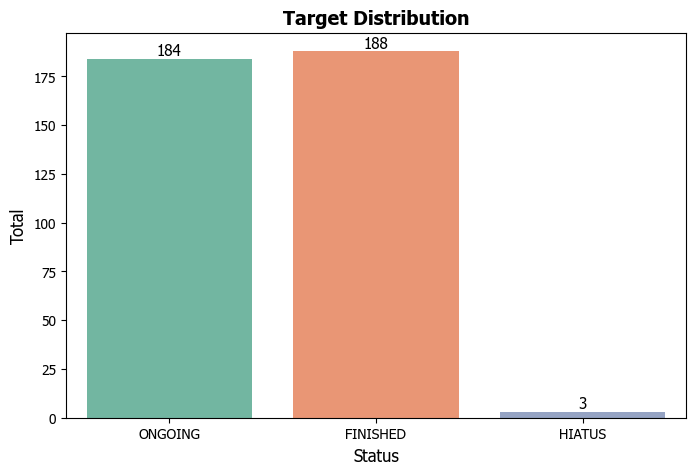

In [42]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_clean, x='jikan_status', palette='Set2', 
                   order=['ONGOING', 'FINISHED', 'HIATUS'])

plt.title('Target Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Status', fontsize=12)
plt.ylabel('Total', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11)

plt.show()

C:\Users\sunsu\AppData\Local\Temp\ipykernel_5788\1157923046.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='jikan_status', y='vol_gap', palette='muted',


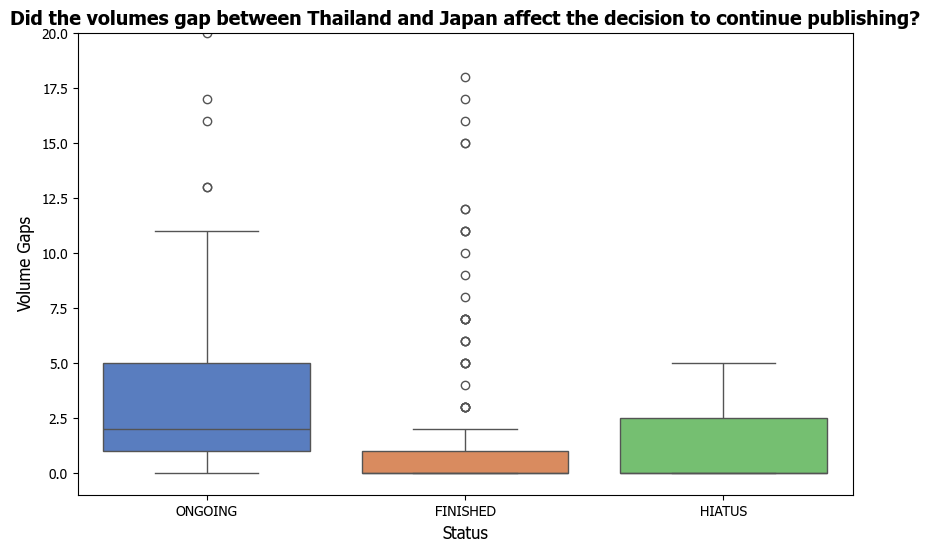

In [43]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='jikan_status', y='vol_gap', palette='muted',
            order=['ONGOING', 'FINISHED', 'HIATUS'])

plt.title('Did the volumes gap between Thailand and Japan affect the decision to continue publishing?', fontsize=14, fontweight='bold')
plt.xlabel('Status', fontsize=12)
plt.ylabel('Volume Gaps', fontsize=12)

plt.ylim(-1, 20) 

plt.show()

status_thai
Safe       278
Dropped     97
Name: count, dtype: int64


C:\Users\sunsu\AppData\Local\Temp\ipykernel_5788\3078364802.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_clean, x='status_thai', palette=['#2ecc71', '#e74c3c'])


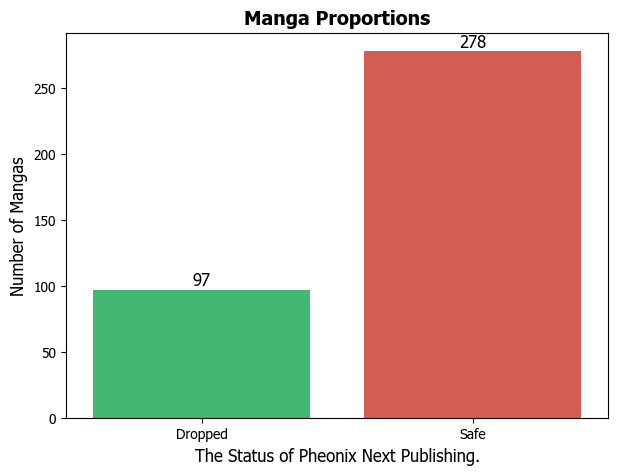

In [44]:
threshold_days = 365

df_clean['is_dropped'] = (
    (df_clean['days_since_last_release'] > threshold_days) & 
    (df_clean['vol_gap'] > 0)
).astype(int)

df_clean['status_thai'] = df_clean['is_dropped'].map({1: 'Dropped', 0: 'Safe'})

print(df_clean['status_thai'].value_counts())

plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df_clean, x='status_thai', palette=['#2ecc71', '#e74c3c'])

plt.title('Manga Proportions', fontsize=14, fontweight='bold')
plt.xlabel('The Status of Pheonix Next Publishing.', fontsize=12)
plt.ylabel('Number of Mangas', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12)

plt.show()

In [45]:
import ast
from sklearn.preprocessing import MultiLabelBinarizer

def parse_genres(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return []
    return []

df_clean['genres_list'] = df_clean['genres'].apply(parse_genres)

mlb = MultiLabelBinarizer()
genres_encoded = pd.DataFrame(mlb.fit_transform(df_clean['genres_list']), 
                              columns=[f"genre_{c}" for c in mlb.classes_], 
                              index=df_clean.index)

df_ml = pd.concat([df_clean, genres_encoded], axis=1)

features_to_drop = [
    'url', 'title_th', 'title_en', 'title_jp', 'authors', 'genres', 'genres_list', 
    'media_type', 'jikan_status', 'latest_th_release', 'first_th_release',
    'days_since_last_release',
    'status_thai'         
]

features_to_drop_v2 = [
    'url', 'title_th', 'title_en', 'title_jp', 'authors', 'genres', 'genres_list', 
    'media_type', 'jikan_status', 'latest_th_release', 'first_th_release',
    'days_since_last_release', 'status_thai',
    
    'vol_gap',        # ตัดทิ้ง เพราะแอบบอกคำเฉลย
    'max_vol_th',     # วันที่ออกเล่ม 1 เรายังไม่รู้ว่าอนาคตจะพิมพ์กี่เล่ม
    'has_premium_count' # เราอาจจะรู้แค่ว่า "เล่ม 1 มีพรีเมียมไหม" แต่ไม่รู้ยอดรวมในอนาคต
]

X = df_ml.drop(columns=features_to_drop_v2 + ['is_dropped'])

y = df_ml['is_dropped']

X = X.fillna(0)

print(f"Prepare Data Successfully!")
print(f"Size of Features (X): {X.shape} (There are a total of {X.shape[1]} variables for the AI ​​to learn from.)")
print(f"Size of Target (y): {y.shape}")

display(X.head())

Prepare Data Successfully!
Size of Features (X): (375, 22) (There are a total of 22 variables for the AI ​​to learn from.)
Size of Target (y): (375,)


,jp_total_vols,avg_price,genre_Action,genre_Adventure,genre_Award Winning,genre_Boys Love,genre_Comedy,genre_Drama,genre_Ecchi,genre_Erotica,...,genre_Gourmet,genre_Hentai,genre_Horror,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Slice of Life,genre_Sports,genre_Supernatural,genre_Suspense
0,8,1150.000000,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,912.500000,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,1,385.000000,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,1,931.666667,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,1,960.000000,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0


Number of data points for training: 300 records
Number of data points for testing: 75 records

Training AI...
Trained!

Classification Report
              precision    recall  f1-score   support

        Safe       0.83      0.95      0.88        56
     Dropped       0.73      0.42      0.53        19

    accuracy                           0.81        75
   macro avg       0.78      0.68      0.71        75
weighted avg       0.80      0.81      0.79        75



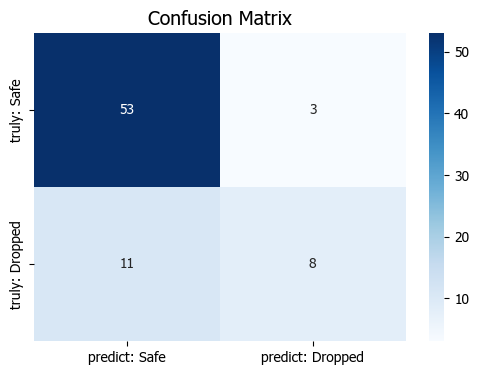

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Number of data points for training: {X_train.shape[0]} records")
print(f"Number of data points for testing: {X_test.shape[0]} records")

model = RandomForestClassifier(n_estimators=100, random_state=42)

print("\nTraining AI...")
model.fit(X_train, y_train)
print("Trained!")

y_pred = model.predict(X_test)

print("\n" + "="*40)
print("Classification Report")
print("="*40)
print(classification_report(y_test, y_pred, target_names=['Safe', 'Dropped']))

plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['predict: Safe', 'predict: Dropped'], 
            yticklabels=['truly: Safe', 'truly: Dropped'])
plt.title('Confusion Matrix', fontsize=14)
plt.show()

C:\Users\sunsu\AppData\Local\Temp\ipykernel_5788\694048121.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df.head(10), x='Importance', y='Feature', palette='magma')


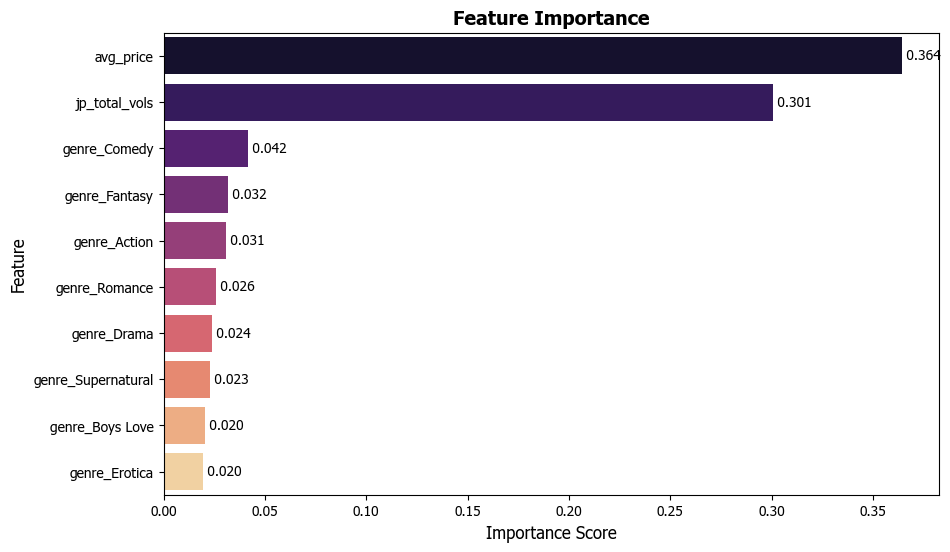

Top 10 Feature:


,Feature,Importance
1,avg_price,0.364130
0,jp_total_vols,0.300892
6,genre_Comedy,0.041892
10,genre_Fantasy,0.031641
2,genre_Action,0.031006
16,genre_Romance,0.026099
7,genre_Drama,0.023717
20,genre_Supernatural,0.023147
5,genre_Boys Love,0.020392
9,genre_Erotica,0.019600


In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importances = model.feature_importances_

fi_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=fi_df.head(10), x='Importance', y='Feature', palette='magma')

plt.title('Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)

for index, value in enumerate(fi_df['Importance'].head(10)):
    plt.text(value, index, f' {value:.3f}', va='center', fontsize=10)

plt.show()

print("Top 10 Feature:")
display(fi_df.head(10))

In [ ]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(model, 'models/manga_survival_model.pkl')

joblib.dump(mlb, 'models/genre_encoder.pkl')

joblib.dump(list(X.columns), 'models/model_features.pkl')

print("Created Model Successfully!")